# OpenRouter Results Analysis (All Runs)

Ce notebook analyse simplement **tous les résultats OpenRouter** de TR-CodeBench.
Il ne fait **aucun appel API** et ne génère aucun candidat.

## Usage rapide

1. Générer des runs depuis le shell :

```bash
./scripts/run_openrouter_eval.sh --models openai/gpt-oss-20b --max-items all --max-workers 4
```

2. Ouvrir ce notebook et exécuter les cellules dans l'ordre.

## Sélection des fichiers

Par défaut, le notebook charge **tous** les fichiers :
`reports/openrouter_runs/openrouter_eval_*.jsonl`

Options possibles :

```bash
# Analyser un seul run
export TRCB_RESULTS_JSONL=reports/openrouter_runs/openrouter_eval_20260512T130403Z.jsonl

# Ou un pattern personnalisé
export TRCB_RESULTS_GLOB='reports/openrouter_runs/openrouter_eval_20260512*.jsonl'
```

Le notebook unifie aussi les anciens et nouveaux schémas de colonnes (`pbt_pass_rate` vs `pbt_gate_passed`/`pbt_group_pass_rate`, etc.).

## 0. Setup

The setup cell only imports local analysis dependencies and locates the repository root.

In [1]:
from __future__ import annotations

import importlib.util
import os
import sys
from pathlib import Path
from typing import Any

missing = []
for package_name, module_name in {
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "python-dotenv": "dotenv",
}.items():
    if importlib.util.find_spec(module_name) is None:
        missing.append(package_name)

if missing:
    raise RuntimeError(
        "Missing notebook dependencies: "
        + ", ".join(missing)
        + ". Run: python3.11 -m pip install -e '.[notebook]'"
    )

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "datasets" / "curated").exists():
            return candidate
    raise RuntimeError("Could not find TR-CodeBench project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC = PROJECT_ROOT / "src"
for path_entry in (str(PROJECT_ROOT), str(SRC)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

from trcodebench.load_items import list_item_ids, load_item

load_dotenv(PROJECT_ROOT / ".env")
RUN_OUTPUT_DIR = PROJECT_ROOT / "reports" / "openrouter_runs"
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Known items: {len(list_item_ids())}")

Project root: /Users/mathiscarlesso/Documents/Cesi/Alteca/Thèse/TR-CodeBench
Known items: 10


## 1. Chargement Unifié Des Résultats

Cette cellule :
- charge un ou plusieurs fichiers JSONL
- ajoute des métadonnées de run (`run_file`, `run_id`, `run_ts`)
- harmonise les colonnes anciennes et nouvelles
- prépare des vues prêtes à analyser (`results_df`, `successful_df`)

In [2]:
import re

def resolve_results_paths() -> list[Path]:
    configured_single = os.getenv("TRCB_RESULTS_JSONL", "").strip() or os.getenv("OPENROUTER_RESULTS_JSONL", "").strip()
    configured_glob = os.getenv("TRCB_RESULTS_GLOB", "").strip()

    if configured_single:
        p = Path(configured_single)
        p = p if p.is_absolute() else PROJECT_ROOT / p
        if not p.exists():
            raise FileNotFoundError(f"Configured result file not found: {p}")
        return [p]

    if configured_glob:
        pattern = configured_glob
        candidates = sorted((PROJECT_ROOT / ".").glob(pattern))
        if not candidates:
            raise FileNotFoundError(f"No files matched TRCB_RESULTS_GLOB={configured_glob}")
        return candidates

    candidates = sorted(RUN_OUTPUT_DIR.glob("openrouter_eval_*.jsonl"))
    if candidates:
        return candidates

    # Fallback: try recursive search from project root
    fallback = sorted(PROJECT_ROOT.glob("**/openrouter_eval_*.jsonl"))
    return fallback


def extract_run_id(path: Path) -> str:
    m = re.search(r"openrouter_eval_(\d{8}T\d{6}Z)", path.name)
    return m.group(1) if m else path.stem


def run_timestamp_from_id(run_id: str) -> pd.Timestamp:
    try:
        return pd.to_datetime(run_id, format="%Y%m%dT%H%M%SZ", utc=True)
    except Exception:
        return pd.NaT


RESULTS_PATHS = resolve_results_paths()

if not RESULTS_PATHS:
    print("No OpenRouter JSONL results found.")
    print("Run: ./scripts/run_openrouter_eval.sh --max-items all --n-runs 1")
    results_df = pd.DataFrame()
    successful_df = pd.DataFrame()
else:
    print("Loading files:")
    for p in RESULTS_PATHS:
        print(" -", p)

    frames: list[pd.DataFrame] = []
    for path in RESULTS_PATHS:
        df_part = pd.read_json(path, lines=True)
        run_id = extract_run_id(path)
        df_part["run_file"] = path.name
        df_part["run_id"] = run_id
        df_part["run_ts"] = run_timestamp_from_id(run_id)
        frames.append(df_part)

    results_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    numeric_cols = [
        "score",
        "correctness_score",
        "optimization_score",
        "pd_score",
        "paradigm_distance",
        "productivity_score",
        "originality_score",
        "public_pass_rate",
        "hidden_pass_rate",
        "pbt_pass_rate",
        "pbt_group_pass_rate",
        "robustness_score",
        "salieri_overlap",
        "complexity_ratio",
        "latency_seconds",
        "prompt_tokens",
        "completion_tokens",
        "total_tokens",
    ]
    for col in numeric_cols:
        if col in results_df.columns:
            results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

    bool_cols = [
        "genuine_divergence",
        "complexity_ratio_ok",
        "hallucination_flag",
        "static_violation",
        "crash",
        "timeout",
        "pbt_gate_passed",
    ]
    for col in bool_cols:
        if col in results_df.columns:
            results_df[col] = results_df[col].fillna(False).astype(bool)
        else:
            results_df[col] = False

    if "pd_score" not in results_df.columns:
        if "pd_candidate" in results_df.columns:
            results_df["pd_score"] = results_df["pd_candidate"].fillna(False).astype(float)
        else:
            results_df["pd_score"] = 0.0

    if "pbt_group_pass_rate" not in results_df.columns:
        if "pbt_pass_rate" in results_df.columns:
            results_df["pbt_group_pass_rate"] = results_df["pbt_pass_rate"]
        else:
            results_df["pbt_group_pass_rate"] = pd.NA

    if "pbt_gate_passed" not in results_df.columns:
        if "pbt_pass_rate" in results_df.columns:
            results_df["pbt_gate_passed"] = results_df["pbt_pass_rate"].fillna(0.0) >= 1.0
        else:
            results_df["pbt_gate_passed"] = False

    if "robustness_score" not in results_df.columns:
        group_rate = pd.to_numeric(results_df["pbt_group_pass_rate"], errors="coerce").fillna(0.0)
        gate_val = results_df["pbt_gate_passed"].astype(float)
        results_df["robustness_score"] = (0.7 * gate_val + 0.3 * group_rate).round(6)

    for col in ["paradigm_distance", "productivity_score", "originality_score"]:
        if col not in results_df.columns:
            results_df[col] = pd.NA

    for required in [
        "public_pass_rate",
        "hidden_pass_rate",
        "score",
        "salieri_overlap",
        "complexity_ratio",
    ]:
        if required not in results_df.columns:
            results_df[required] = pd.NA

    for text_col in ["candidate_paradigms", "oracle_paradigms", "static_violations"]:
        if text_col not in results_df.columns:
            results_df[text_col] = ""

    results_df["public_hidden_gap"] = results_df["public_pass_rate"] - results_df["hidden_pass_rate"]

    if "api_error" in results_df.columns:
        successful_df = results_df[results_df["api_error"].isna()].copy()
    else:
        successful_df = results_df.copy()

    print(f"Files: {len(RESULTS_PATHS)} | Rows: {len(results_df)} | successful API rows: {len(successful_df)}")
    display(results_df.head())

Loading files:
 - /Users/mathiscarlesso/Documents/Cesi/Alteca/Thèse/TR-CodeBench/reports/openrouter_runs/openrouter_eval_20260512T220239Z.jsonl
Files: 1 | Rows: 50 | successful API rows: 40


,api_error,candidate_paradigms,candidate_path,completion_tokens,complexity_ratio,complexity_ratio_ok,correctness_score,crash,created_utc,genuine_divergence,...,static_violation,static_violations,timeout,total_tokens,run_file,run_ts,pbt_gate_passed,pbt_group_pass_rate,robustness_score,public_hidden_gap
0,None,"topological_dp,relaxation_in_known_topological...",/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,610.0,1.258506,True,1.0,False,2026-05-12T22:03:06.039889+00:00,False,...,False,,False,1177.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
1,None,patience_sorting,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,1052.0,1.265990,True,1.0,False,2026-05-12T22:03:13.647065+00:00,False,...,False,,False,1581.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
2,None,greedy_by_finish_time,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,935.0,0.887826,True,1.0,False,2026-05-12T22:03:16.047536+00:00,False,...,False,,False,1429.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
3,None,union_find,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,976.0,1.328119,True,1.0,False,2026-05-12T22:03:16.382152+00:00,False,...,False,,False,1535.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
4,None,"dijkstra_heap,a_star_with_zero_heuristic",/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,1038.0,1.001363,True,1.0,False,2026-05-12T22:03:19.790190+00:00,False,...,False,,False,1665.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0


## 2. Santé Des Données (Vue Rapide)

Vue synthétique pour vérifier immédiatement :
- couverture des modèles / items / runs
- erreurs API
- disponibilité des champs v0.2
- cohérence des colonnes PBT

In [3]:
health = {
    "rows": len(results_df),
    "models": results_df["model"].nunique() if "model" in results_df else 0,
    "items": results_df["item_id"].nunique() if "item_id" in results_df else 0,
    "runs": results_df["run_id"].nunique() if "run_id" in results_df else 0,
    "api_errors": int(results_df["api_error"].notna().sum()) if "api_error" in results_df else 0,
    "missing_score": int(results_df["score"].isna().sum()) if "score" in results_df else len(results_df),
    "timeouts": int(results_df["timeout"].sum()) if "timeout" in results_df else 0,
    "crashes": int(results_df["crash"].sum()) if "crash" in results_df else 0,
    "has_pd_score": "pd_score" in results_df.columns and results_df["pd_score"].notna().any(),
    "has_paradigm_distance": "paradigm_distance" in results_df.columns and results_df["paradigm_distance"].notna().any(),
    "has_productivity_score": "productivity_score" in results_df.columns and results_df["productivity_score"].notna().any(),
    "has_pbt_gate_passed": "pbt_gate_passed" in results_df.columns,
    "has_pbt_group_pass_rate": "pbt_group_pass_rate" in results_df.columns,
    "has_robustness_score": "robustness_score" in results_df.columns,
}
display(pd.DataFrame([health]).T.rename(columns={0: "value"}))

if "run_id" in results_df.columns:
    run_health = (
        results_df.groupby(["run_id", "run_file"], dropna=False)
        .agg(
            rows=("item_id", "count"),
            models=("model", "nunique"),
            items=("item_id", "nunique"),
            score_mean=("score", "mean"),
            correctness_mean=("correctness_score", "mean"),
            pd_score_mean=("pd_score", "mean"),
            api_errors=("api_error", lambda s: s.notna().sum()) if "api_error" in results_df.columns else ("item_id", "count"),
        )
        .sort_index()
    )
    display(run_health.round(3))

if "api_error" in results_df.columns:
    errors = results_df[results_df["api_error"].notna()][["run_id", "model", "item_id", "run_index", "api_error"]]
    if not errors.empty:
        display(errors)

,value
rows,50
models,5
items,10
runs,1
api_errors,10
missing_score,10
timeouts,2
crashes,7
has_pd_score,True
has_paradigm_distance,True


,,rows,models,items,score_mean,correctness_mean,pd_score_mean,api_errors
run_id,run_file,,,,,,,
20260512T220239Z,openrouter_eval_20260512T220239Z.jsonl,50,5,10,0.675,0.8,0.047,10


,run_id,model,item_id,run_index,api_error
24,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0001,0,HTTPError: 429 Client Error: Too Many Requests...
25,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0002,0,HTTPError: 429 Client Error: Too Many Requests...
26,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0003,0,HTTPError: 429 Client Error: Too Many Requests...
27,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0004,0,HTTPError: 429 Client Error: Too Many Requests...
29,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0005,0,HTTPError: 429 Client Error: Too Many Requests...
30,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0006,0,HTTPError: 429 Client Error: Too Many Requests...
31,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0007,0,HTTPError: 429 Client Error: Too Many Requests...
32,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0008,0,HTTPError: 429 Client Error: Too Many Requests...
33,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0009,0,HTTPError: 429 Client Error: Too Many Requests...
35,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0010,0,HTTPError: 429 Client Error: Too Many Requests...


## 3. Tableaux De Synthèse (Intuitifs)

Trois niveaux de lecture :
- **par run** : évolution globale d'une exécution à l'autre
- **par modèle** : performance moyenne sur l'ensemble des runs
- **par item** : difficulté intrinsèque des tâches

In [4]:
if results_df.empty:
    print("Aucune donnée chargée. Exécutez d'abord un run OpenRouter.")
    run_summary = pd.DataFrame()
    summary = pd.DataFrame()
    by_item = pd.DataFrame()
else:
    run_agg = {
        "rows": ("item_id", "count"),
        "models": ("model", "nunique"),
        "items": ("item_id", "nunique"),
        "score_mean": ("score", "mean"),
        "correctness_rate": ("correctness_score", "mean"),
        "optimization_rate": ("optimization_score", "mean"),
        "pd_score_mean": ("pd_score", "mean"),
        "robustness_mean": ("robustness_score", "mean"),
        "pbt_gate_rate": ("pbt_gate_passed", "mean"),
        "pbt_group_mean": ("pbt_group_pass_rate", "mean"),
        "hallucination_rate": ("hallucination_flag", "mean"),
        "timeout_rate": ("timeout", "mean"),
        "salieri_overlap_mean": ("salieri_overlap", "mean"),
    }
    if "api_error" in results_df.columns:
        run_agg["api_errors"] = ("api_error", lambda s: s.notna().sum())

    run_summary = (
        results_df.groupby(["run_id", "run_file"], dropna=False)
        .agg(**run_agg)
        .sort_values("run_id")
    )
    display(run_summary.round(3))

    model_agg = {
        "requests": ("item_id", "count"),
        "runs": ("run_id", "nunique"),
        "score_mean": ("score", "mean"),
        "correctness_rate": ("correctness_score", "mean"),
        "optimization_rate": ("optimization_score", "mean"),
        "hidden_pass_mean": ("hidden_pass_rate", "mean"),
        "pbt_gate_rate": ("pbt_gate_passed", "mean"),
        "pbt_group_mean": ("pbt_group_pass_rate", "mean"),
        "robustness_mean": ("robustness_score", "mean"),
        "pd_score_mean": ("pd_score", "mean"),
        "hallucination_rate": ("hallucination_flag", "mean"),
        "static_violation_rate": ("static_violation", "mean"),
        "timeout_rate": ("timeout", "mean"),
        "salieri_overlap_mean": ("salieri_overlap", "mean"),
        "public_hidden_gap_mean": ("public_hidden_gap", "mean"),
        "latency_seconds_mean": ("latency_seconds", "mean"),
        "total_tokens_mean": ("total_tokens", "mean"),
    }
    if "paradigm_distance" in results_df.columns:
        model_agg["paradigm_dist_mean"] = ("paradigm_distance", "mean")
    if "productivity_score" in results_df.columns:
        model_agg["productivity_mean"] = ("productivity_score", "mean")
    if "api_error" in results_df.columns:
        model_agg["api_errors"] = ("api_error", lambda s: s.notna().sum())

    summary = (
        results_df.groupby("model", dropna=False)
        .agg(**model_agg)
        .sort_values("score_mean", ascending=False)
    )
    display(summary.round(3))

    item_agg = {
        "attempts": ("model", "count"),
        "runs": ("run_id", "nunique"),
        "score_mean": ("score", "mean"),
        "correctness_rate": ("correctness_score", "mean"),
        "optimization_rate": ("optimization_score", "mean"),
        "hidden_pass_mean": ("hidden_pass_rate", "mean"),
        "pbt_gate_rate": ("pbt_gate_passed", "mean"),
        "pbt_group_mean": ("pbt_group_pass_rate", "mean"),
        "pd_score_mean": ("pd_score", "mean"),
        "hallucination_rate": ("hallucination_flag", "mean"),
        "public_hidden_gap_mean": ("public_hidden_gap", "mean"),
    }
    if "paradigm_distance" in results_df.columns:
        item_agg["paradigm_dist_mean"] = ("paradigm_distance", "mean")
    if "complexity_ratio_ok" in results_df.columns:
        item_agg["complexity_ok_rate"] = ("complexity_ratio_ok", "mean")

    by_item = (
        results_df.groupby("item_id", dropna=False)
        .agg(**item_agg)
        .sort_values("score_mean")
    )
    display(by_item.round(3))

,,rows,models,items,score_mean,correctness_rate,optimization_rate,pd_score_mean,robustness_mean,pbt_gate_rate,pbt_group_mean,hallucination_rate,timeout_rate,salieri_overlap_mean,api_errors
run_id,run_file,,,,,,,,,,,,,,
20260512T220239Z,openrouter_eval_20260512T220239Z.jsonl,50,5,10,0.675,0.8,0.75,0.047,0.0,0.0,NaN,0.16,0.04,0.538,10


,requests,runs,score_mean,correctness_rate,optimization_rate,hidden_pass_mean,pbt_gate_rate,pbt_group_mean,robustness_mean,pd_score_mean,hallucination_rate,static_violation_rate,timeout_rate,salieri_overlap_mean,public_hidden_gap_mean,latency_seconds_mean,total_tokens_mean,paradigm_dist_mean,productivity_mean,api_errors
model,,,,,,,,,,,,,,,,,,,,
poolside/laguna-m.1:free,10,1,0.864,1.0,1.0,1.000,0.0,NaN,0.0,0.094,0.0,0.0,0.0,0.510,0.000,32.975,2049.3,0.059,0.976,0
openai/gpt-oss-20b,10,1,0.833,1.0,0.9,1.000,0.0,NaN,0.0,0.052,0.0,0.0,0.0,0.523,0.000,2.981,972.6,0.033,0.878,0
qwen/qwen3-235b-a22b-2507,10,1,0.771,0.9,0.9,0.903,0.0,NaN,0.0,0.042,0.1,0.0,0.0,0.515,-0.003,17.462,762.0,0.029,0.879,0
nvidia/nemotron-3-nano-30b-a3b:free,10,1,0.230,0.3,0.2,0.397,0.0,NaN,0.0,0.000,0.7,0.5,0.2,0.605,0.003,3.614,1257.7,0.400,0.292,0
mistralai/mistral-small-24b-instruct-2501,10,1,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,10


,attempts,runs,score_mean,correctness_rate,optimization_rate,hidden_pass_mean,pbt_gate_rate,pbt_group_mean,pd_score_mean,hallucination_rate,public_hidden_gap_mean,paradigm_dist_mean,complexity_ok_rate
item_id,,,,,,,,,,,,,
trcb-proto-0010,5,1,0.575,0.75,0.50,0.750,0.0,NaN,0.000,0.2,0.000,0.250,0.4
trcb-proto-0001,5,1,0.638,0.75,0.75,0.750,0.0,NaN,0.000,0.2,0.000,0.000,0.6
trcb-proto-0002,5,1,0.638,0.75,0.75,0.750,0.0,NaN,0.000,0.2,0.000,0.250,0.6
trcb-proto-0003,5,1,0.638,0.75,0.75,0.750,0.0,NaN,0.000,0.2,0.000,0.000,0.6
trcb-proto-0007,5,1,0.638,0.75,0.75,0.750,0.0,NaN,0.000,0.2,0.000,0.250,0.6
trcb-proto-0008,5,1,0.638,0.75,0.75,0.992,0.0,NaN,0.000,0.2,0.008,0.009,0.8
trcb-proto-0009,5,1,0.638,0.75,0.75,0.758,0.0,NaN,0.000,0.2,-0.008,0.000,0.6
trcb-proto-0005,5,1,0.669,0.75,0.75,0.750,0.0,NaN,0.207,0.2,0.000,0.396,0.6
trcb-proto-0006,5,1,0.827,1.00,0.75,1.000,0.0,NaN,0.262,0.0,0.000,0.146,0.6


## 4. Graphiques Clés (Lecture Immédiate)

Cette vue compacte répond à 4 questions :
1. Quels modèles dominent globalement ?
2. Où sont les gaps public/hidden/PBT ?
3. Comment évoluent les runs dans le temps ?
4. Le score dépend-il d'un overlap oracle élevé ?

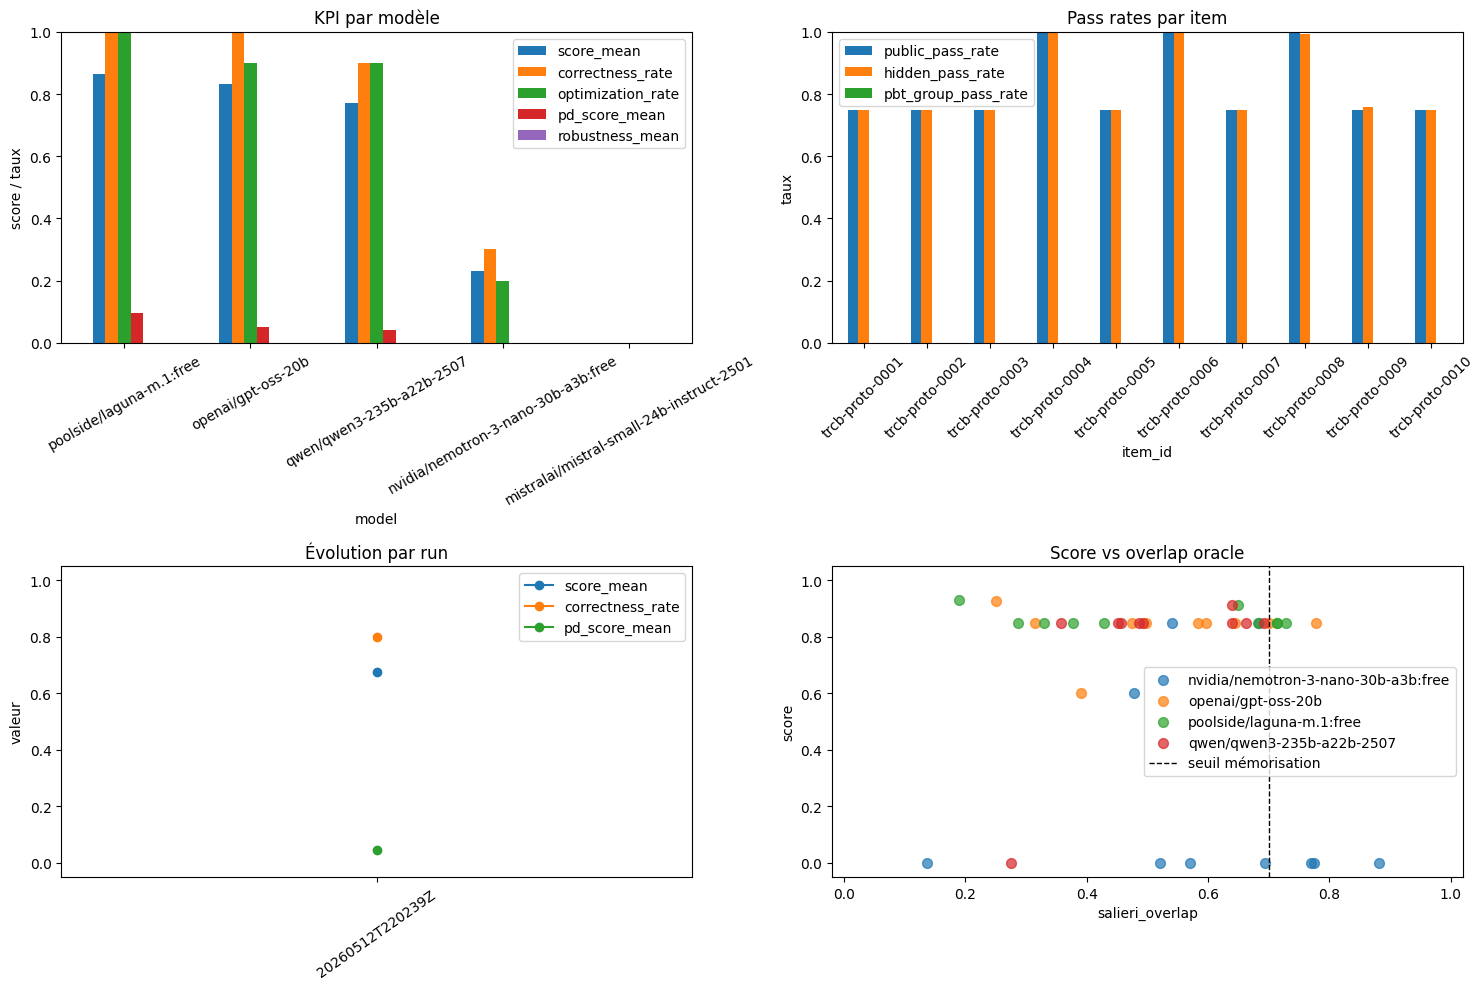

In [5]:
if successful_df.empty:
    print("No successful API rows to plot.")
else:
    plt.style.use("default")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1) KPI modèle
    kpi_cols = ["score_mean", "correctness_rate", "optimization_rate", "pd_score_mean", "robustness_mean"]
    kpi_cols = [c for c in kpi_cols if c in summary.columns]
    summary[kpi_cols].plot(kind="bar", ax=axes[0, 0], ylim=(0, 1), rot=30)
    axes[0, 0].set_title("KPI par modèle")
    axes[0, 0].set_ylabel("score / taux")

    # 2) Public vs hidden vs PBT
    rate_cols = [c for c in ["public_pass_rate", "hidden_pass_rate", "pbt_group_pass_rate"] if c in successful_df.columns]
    if rate_cols:
        successful_df.groupby("item_id")[rate_cols].mean().plot(
            kind="bar", ax=axes[0, 1], ylim=(0, 1), rot=45
        )
        axes[0, 1].set_title("Pass rates par item")
        axes[0, 1].set_ylabel("taux")
    else:
        axes[0, 1].text(0.5, 0.5, "Pass rates indisponibles", ha="center", va="center", transform=axes[0, 1].transAxes)

    # 3) Évolution score moyen par run
    if "run_ts" in run_summary.reset_index().columns:
        run_plot = run_summary.reset_index().sort_values("run_ts")
    else:
        run_plot = run_summary.reset_index().sort_values("run_id")
    axes[1, 0].plot(run_plot["run_id"], run_plot["score_mean"], marker="o", label="score_mean")
    if "correctness_rate" in run_plot.columns:
        axes[1, 0].plot(run_plot["run_id"], run_plot["correctness_rate"], marker="o", label="correctness_rate")
    if "pd_score_mean" in run_plot.columns:
        axes[1, 0].plot(run_plot["run_id"], run_plot["pd_score_mean"], marker="o", label="pd_score_mean")
    axes[1, 0].set_title("Évolution par run")
    axes[1, 0].set_ylabel("valeur")
    axes[1, 0].tick_params(axis="x", rotation=35)
    axes[1, 0].set_ylim(-0.05, 1.05)
    axes[1, 0].legend(loc="best")

    # 4) Score vs overlap oracle
    if "salieri_overlap" in successful_df.columns:
        for model, group in successful_df.groupby("model"):
            axes[1, 1].scatter(group["salieri_overlap"], group["score"], label=model, alpha=0.7, s=50)
        axes[1, 1].axvline(0.70, color="black", linestyle="--", linewidth=1, label="seuil mémorisation")
        axes[1, 1].set_xlim(-0.02, 1.02)
        axes[1, 1].set_ylim(-0.05, 1.05)
        axes[1, 1].set_xlabel("salieri_overlap")
        axes[1, 1].set_ylabel("score")
        axes[1, 1].set_title("Score vs overlap oracle")
        axes[1, 1].legend(loc="best")
    else:
        axes[1, 1].text(0.5, 0.5, "salieri_overlap indisponible", ha="center", va="center", transform=axes[1, 1].transAxes)

    plt.tight_layout()
    plt.show()

## 5. Score Heatmap

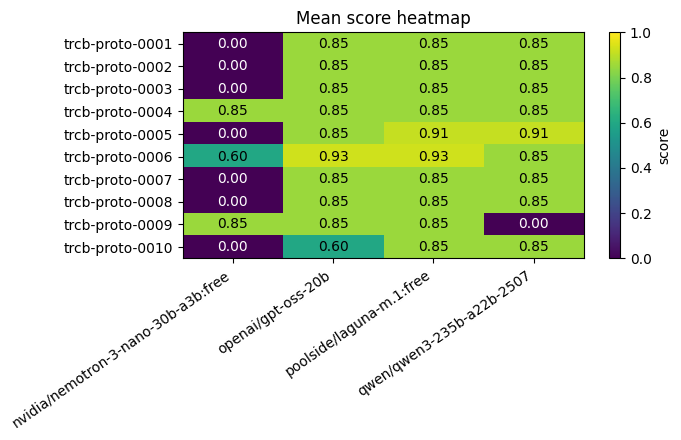

In [6]:
if successful_df.empty:
    print("No successful API rows for heatmap.")
else:
    pivot = successful_df.pivot_table(index="item_id", columns="model", values="score", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(pivot.columns)), max(4, 0.45 * len(pivot.index))))
    image = ax.imshow(pivot.fillna(0).values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Mean score heatmap")
    for row_idx, item_id in enumerate(pivot.index):
        for col_idx, model in enumerate(pivot.columns):
            value = pivot.loc[item_id, model]
            label = "" if pd.isna(value) else f"{value:.2f}"
            ax.text(col_idx, row_idx, label, ha="center", va="center", color="white" if (value or 0) < 0.55 else "black")
    fig.colorbar(image, ax=ax, label="score")
    plt.tight_layout()
    plt.show()

## 6. Productive Divergence — Analyse 3 Axes

Le score de divergence productive reste continu :
`pd_score = HM(paradigm_distance, productivity_score, originality_score)`

Axes :
- **paradigm_distance** : distance structurelle de paradigme
- **productivity_score** : efficacité + robustesse
- **originality_score** : `1 - salieri_overlap`

Repères utiles :
- `salieri_overlap > 0.70` : zone de mémorisation
- `paradigm_distance < 0.20` : variation surtout cosmétique

In [7]:
pd_cols = [
    "run_id", "model", "item_id", "run_index", "score",
    "correctness_score", "pd_score",
    "paradigm_distance", "productivity_score", "originality_score",
    "salieri_overlap", "genuine_divergence",
    "pbt_gate_passed", "pbt_group_pass_rate", "robustness_score",
    "candidate_paradigms", "oracle_paradigms",
    "hidden_pass_rate",
    "candidate_path",
]
pd_cols = [col for col in pd_cols if col in successful_df.columns]

if successful_df.empty:
    print("No successful API rows for productive divergence drilldown.")
else:
    if "originality_score" not in successful_df.columns and "salieri_overlap" in successful_df.columns:
        successful_df["originality_score"] = 1.0 - successful_df["salieri_overlap"]

    drilldown = successful_df[pd_cols].sort_values("pd_score", ascending=False)
    display(drilldown.head(30).reset_index(drop=True))

    pd_active = successful_df[successful_df["pd_score"] > 0.0]
    print(f"\nRows with pd_score > 0: {len(pd_active)} / {len(successful_df)}")
    if not pd_active.empty:
        print(f"Mean pd_score (active only): {pd_active['pd_score'].mean():.4f}")

    for _, row in pd_active.head(3).iterrows():
        print(f"\n--- {row['model']}  {row['item_id']}  pd_score={row.get('pd_score', 0.0):.4f} ---")
        path = Path(row["candidate_path"]) if "candidate_path" in row.index else None
        if path and path.exists():
            print(path.read_text(encoding="utf-8")[:800])

,run_id,model,item_id,run_index,score,correctness_score,pd_score,paradigm_distance,productivity_score,originality_score,salieri_overlap,genuine_divergence,pbt_gate_passed,pbt_group_pass_rate,robustness_score,candidate_paradigms,oracle_paradigms,hidden_pass_rate,candidate_path
0,20260512T220239Z,poolside/laguna-m.1:free,trcb-proto-0006,0,0.929254,1.0,0.528358,0.292893,0.971051,0.810409,0.189591,False,False,NaN,0.0,,kmp,1.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
1,20260512T220239Z,openai/gpt-oss-20b,trcb-proto-0006,0,0.927930,1.0,0.519536,0.292893,0.973871,0.750000,0.250000,False,False,NaN,0.0,kmp,kmp,1.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
2,20260512T220239Z,qwen/qwen3-235b-a22b-2507,trcb-proto-0005,0,0.912410,1.0,0.416069,0.292893,0.977141,0.360656,0.639344,False,False,NaN,0.0,union_find,union_find,1.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
3,20260512T220239Z,poolside/laguna-m.1:free,trcb-proto-0005,0,0.911649,1.0,0.410992,0.292893,0.972713,0.350000,0.650000,False,False,NaN,0.0,union_find,union_find,1.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
4,20260512T220239Z,poolside/laguna-m.1:free,trcb-proto-0008,0,0.850000,1.0,0.000000,0.000000,0.967515,0.318182,0.681818,False,False,NaN,0.0,"topological_dp,relaxation_in_known_topological...","topological_dp,relaxation_in_known_topological...",1.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
5,20260512T220239Z,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0002,0,0.000000,0.0,0.000000,1.000000,0.000000,0.306818,0.693182,False,False,NaN,0.0,,"dijkstra_heap,a_star_with_zero_heuristic",0.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
6,20260512T220239Z,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0001,0,0.000000,0.0,0.000000,0.000000,0.000000,0.118644,0.881356,False,False,NaN,0.0,patience_sorting,patience_sorting,0.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
7,20260512T220239Z,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0005,0,0.000000,0.0,0.000000,1.000000,0.000000,0.224852,0.775148,False,False,NaN,0.0,,union_find,0.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
8,20260512T220239Z,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0003,0,0.000000,0.0,0.000000,0.000000,0.000000,0.862745,0.137255,False,False,NaN,0.0,greedy_by_finish_time,greedy_by_finish_time,0.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
9,20260512T220239Z,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0007,0,0.000000,0.0,0.000000,1.000000,0.000000,0.229508,0.770492,True,False,NaN,0.0,block_prefix_suffix,monotonic_deque,0.000000,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...



Rows with pd_score > 0: 4 / 40
Mean pd_score (active only): 0.4687

--- poolside/laguna-m.1:free  trcb-proto-0005  pd_score=0.4110 ---
def solve(n: int, unions: list[tuple[int, int]], queries: list[tuple[int, int]]) -> list[bool]:
    parent = list(range(n))
    rank = [0] * n
    
    def find(x: int) -> int:
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]
    
    def union(x: int, y: int):
        px, py = find(x), find(y)
        if px == py:
            return
        if rank[px] < rank[py]:
            parent[px] = py
        elif rank[px] > rank[py]:
            parent[py] = px
        else:
            parent[py] = px
            rank[px] += 1
    
    for u, v in unions:
        union(u, v)
    
    return [find(u) == find(v) for u, v in queries]

# COMPLEXITY: O((n + m + q) * alpha(n)) where m = len(unions), q = len(queries)
# PARADIGM: union_find with path compression

--- openai/gpt-oss-20b  trcb-proto-0006  pd_score=0.5195 ---
f

### 6a. PD Axes Scatter Matrix

Pairwise scatter of the three PD axes (paradigm distance, productivity, originality) coloured by model. Only correct candidates shown.

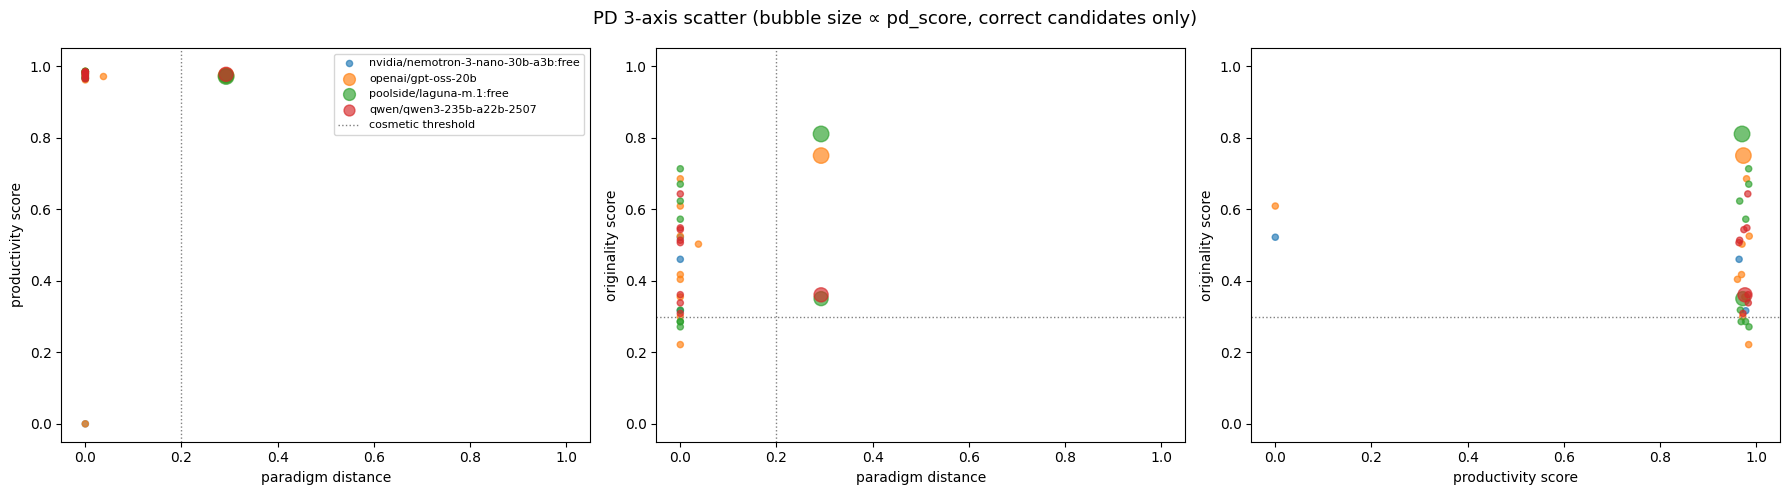

In [8]:
correct_df = successful_df[successful_df["correctness_score"] == 1.0].copy()
if "originality_score" not in correct_df.columns and "salieri_overlap" in correct_df.columns:
    correct_df["originality_score"] = 1.0 - correct_df["salieri_overlap"]

axis_cols = ["paradigm_distance", "productivity_score", "originality_score"]
has_axes = all(c in correct_df.columns and correct_df[c].notna().any() for c in axis_cols)

if correct_df.empty or not has_axes:
    print("Not enough 3-axis PD data for scatter matrix.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pairs = [
        ("paradigm_distance", "productivity_score"),
        ("paradigm_distance", "originality_score"),
        ("productivity_score", "originality_score"),
    ]
    for ax, (xc, yc) in zip(axes, pairs):
        for model, grp in correct_df.groupby("model"):
            size = grp["pd_score"].clip(lower=0) * 200 + 20
            ax.scatter(grp[xc], grp[yc], s=size, alpha=0.65, label=model)
        ax.set_xlabel(xc.replace("_", " "))
        ax.set_ylabel(yc.replace("_", " "))
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        # Threshold lines
        if xc == "paradigm_distance":
            ax.axvline(0.20, color="gray", linestyle=":", lw=1, label="cosmetic threshold")
        if yc == "originality_score":
            ax.axhline(0.30, color="gray", linestyle=":", lw=1, label="memorisation zone")

    axes[0].legend(loc="best", fontsize=8)
    fig.suptitle("PD 3-axis scatter (bubble size ∝ pd_score, correct candidates only)", fontsize=13)
    plt.tight_layout()
    plt.show()

### 6b. PD Score Distribution & Radar per Model

Left: pd_score histogram by model. Right: mean radar across the 3 PD axes per model.

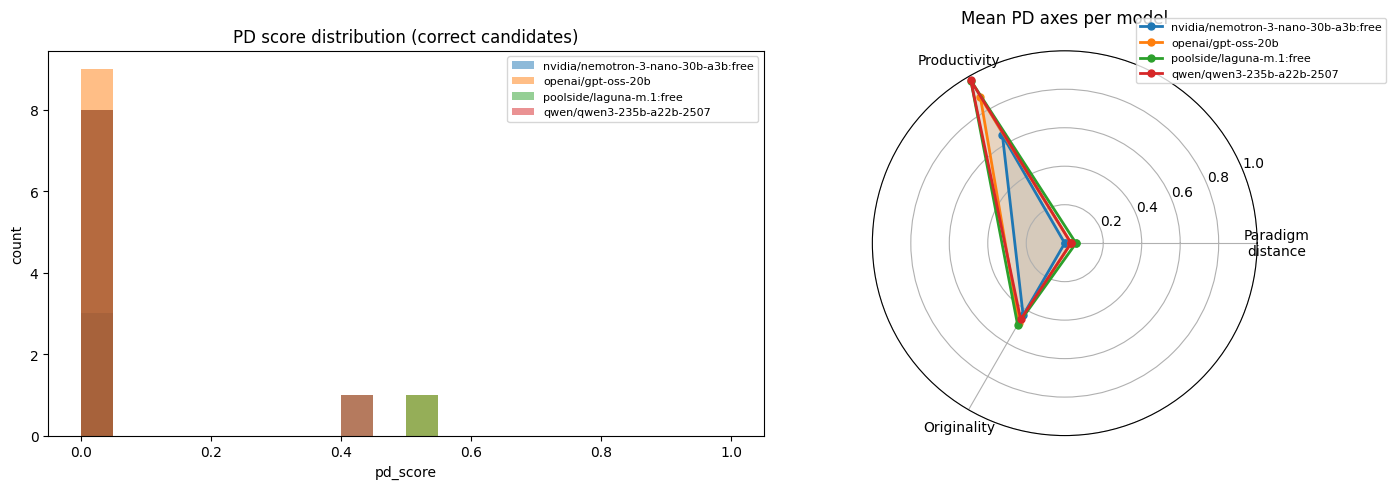

In [9]:
import numpy as np

if correct_df.empty:
    print("No correct candidates for PD distribution analysis.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- Left: pd_score histogram ---
    models = correct_df["model"].unique()
    for model in sorted(models):
        values = correct_df.loc[correct_df["model"] == model, "pd_score"].dropna()
        axes[0].hist(values, bins=20, alpha=0.5, label=model, range=(0, 1))
    axes[0].set_xlabel("pd_score")
    axes[0].set_ylabel("count")
    axes[0].set_title("PD score distribution (correct candidates)")
    axes[0].legend(loc="best", fontsize=8)

    # --- Right: radar chart of mean PD axes per model ---
    radar_cols = ["paradigm_distance", "productivity_score", "originality_score"]
    if all(c in correct_df.columns for c in radar_cols):
        model_means = correct_df.groupby("model")[radar_cols].mean()
        labels = ["Paradigm\ndistance", "Productivity", "Originality"]
        angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]

        ax_radar = fig.add_subplot(122, polar=True)
        axes[1].set_visible(False)

        for model in model_means.index:
            values = model_means.loc[model].tolist()
            values += values[:1]
            ax_radar.plot(angles, values, "o-", linewidth=2, label=model, markersize=5)
            ax_radar.fill(angles, values, alpha=0.1)
        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(labels, fontsize=10)
        ax_radar.set_ylim(0, 1)
        ax_radar.set_title("Mean PD axes per model", pad=20)
        ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Axis data not available", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Radar (no data)")

    plt.tight_layout()
    plt.show()

### 6c. PD Score Heatmap (item × model)

Continuous pd_score per item and model. Higher values indicate genuine productive divergence.

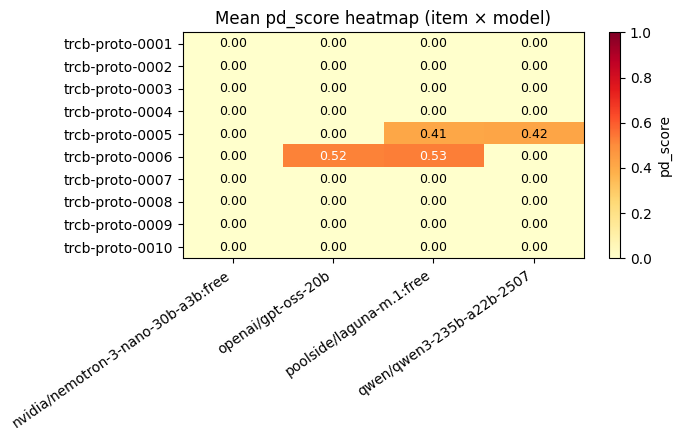

In [10]:
if successful_df.empty or "pd_score" not in successful_df.columns:
    print("No pd_score data for heatmap.")
else:
    pivot_pd = successful_df.pivot_table(index="item_id", columns="model", values="pd_score", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(pivot_pd.columns)), max(4, 0.45 * len(pivot_pd.index))))
    image = ax.imshow(pivot_pd.fillna(0).values, vmin=0, vmax=1, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot_pd.columns)))
    ax.set_xticklabels(pivot_pd.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(pivot_pd.index)))
    ax.set_yticklabels(pivot_pd.index)
    ax.set_title("Mean pd_score heatmap (item × model)")
    for ri, item_id in enumerate(pivot_pd.index):
        for ci, model in enumerate(pivot_pd.columns):
            val = pivot_pd.loc[item_id, model]
            label = "" if pd.isna(val) else f"{val:.2f}"
            ax.text(ci, ri, label, ha="center", va="center", color="white" if (val or 0) > 0.45 else "black", fontsize=9)
    fig.colorbar(image, ax=ax, label="pd_score")
    plt.tight_layout()
    plt.show()

## 7. True Regime / Complexity Analysis

,model,item_id,score,correctness_score,optimization_score,complexity_ratio_ok,complexity_ratio,timeout,candidate_path
0,openai/gpt-oss-20b,trcb-proto-0010,0.600000,1.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
1,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0006,0.600000,1.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
2,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0002,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
3,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0001,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
4,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0005,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
5,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0003,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
6,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0007,0.000000,0.0,0.0,False,NaN,True,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
7,nvidia/nemotron-3-nano-30b-a3b:free,trcb-proto-0010,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
8,qwen/qwen3-235b-a22b-2507,trcb-proto-0009,0.000000,0.0,0.0,False,NaN,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...
9,openai/gpt-oss-20b,trcb-proto-0002,0.850000,1.0,1.0,True,1.872054,False,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...


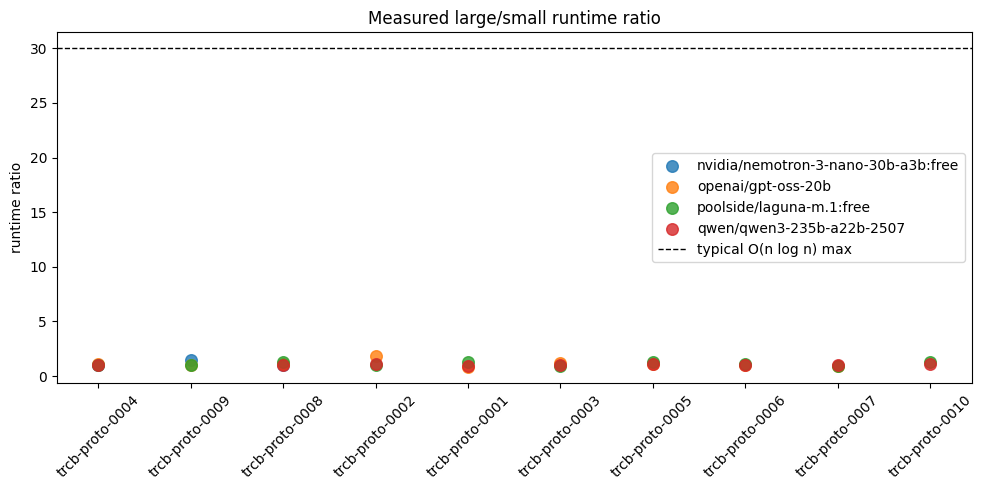

In [11]:
complexity_cols = [
    "model",
    "item_id",
    "score",
    "correctness_score",
    "optimization_score",
    "complexity_ratio_ok",
    "complexity_ratio",
    "timeout",
    "candidate_path",
]
complexity_cols = [col for col in complexity_cols if col in successful_df.columns]
if successful_df.empty or "complexity_ratio_ok" not in successful_df.columns:
    print("No v0.2 complexity fields found in this result file.")
else:
    display(
        successful_df[complexity_cols]
        .sort_values(["complexity_ratio_ok", "complexity_ratio"], ascending=[True, False])
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_data = successful_df.dropna(subset=["complexity_ratio"]).copy()
    if plot_data.empty:
        print("No measured complexity ratios available.")
    else:
        for model, group in plot_data.groupby("model"):
            ax.scatter(group["item_id"], group["complexity_ratio"], label=model, s=70, alpha=0.8)
        ax.axhline(30, color="black", linestyle="--", linewidth=1, label="typical O(n log n) max")
        ax.set_title("Measured large/small runtime ratio")
        ax.set_ylabel("runtime ratio")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()

## 8. Failure Analysis

In [12]:
if results_df.empty:
    print("Aucune donnée pour l'analyse des échecs.")
    failures = pd.DataFrame()
    display(failures)
else:
    failure_mask = pd.Series(False, index=results_df.index)
    for col in ["api_error", "hallucination_flag", "static_violation", "crash", "timeout"]:
        if col in results_df.columns:
            if col == "api_error":
                failure_mask = failure_mask | results_df[col].notna()
            else:
                failure_mask = failure_mask | results_df[col].fillna(False).astype(bool)

    failure_cols = [
        "run_id",
        "model",
        "item_id",
        "run_index",
        "score",
        "api_error",
        "hallucination_flag",
        "static_violation",
        "crash",
        "timeout",
        "hidden_pass_rate",
        "pbt_gate_passed",
        "pbt_group_pass_rate",
        "robustness_score",
        "static_violations",
        "candidate_path",
    ]
    failure_cols = [col for col in failure_cols if col in results_df.columns]
    failures = results_df[failure_mask][failure_cols]

    if "run_id" in failures.columns and "model" in failures.columns and "item_id" in failures.columns:
        sort_cols = [c for c in ["run_id", "model", "item_id", "run_index"] if c in failures.columns]
    else:
        sort_cols = [c for c in ["model", "item_id", "run_index"] if c in failures.columns]

    if sort_cols:
        failures = failures.sort_values(sort_cols)

    print(f"Failure-like rows: {len(failures)}")
    display(failures.reset_index(drop=True))

Failure-like rows: 18


,run_id,model,item_id,run_index,score,api_error,hallucination_flag,static_violation,crash,timeout,hidden_pass_rate,pbt_gate_passed,pbt_group_pass_rate,robustness_score,static_violations,candidate_path
0,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0001,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
1,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0002,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
2,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0003,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
3,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0004,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
4,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0005,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
5,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0006,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
6,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0007,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
7,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0008,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
8,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0009,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None
9,20260512T220239Z,mistralai/mistral-small-24b-instruct-2501,trcb-proto-0010,0,NaN,HTTPError: 429 Client Error: Too Many Requests...,False,False,False,False,NaN,False,NaN,0.0,,None


## 9. UX — Filtres Globaux

Cette section permet de filtrer toute l'analyse rapidement, sans modifier les cellules précédentes.

Utilisation :
- laisser `None` pour ne pas filtrer
- mettre une liste pour filtrer (ex: `["openai/gpt-oss-20b"]`)
- utiliser `TOP_N_RUNS` pour ne garder que les derniers runs

In [13]:
# Filtres globaux (modifiez ici uniquement)
FILTER_MODELS: list[str] | None = None
FILTER_RUN_IDS: list[str] | None = None
FILTER_ITEM_IDS: list[str] | None = None
TOP_N_RUNS: int | None = None  # ex: 3 pour garder les 3 runs les plus récents

if results_df.empty:
    results_view_df = results_df.copy()
    successful_view_df = successful_df.copy()
    print("Aucune donnée à filtrer.")
else:
    mask = pd.Series(True, index=results_df.index)

    if FILTER_MODELS:
        mask &= results_df["model"].isin(FILTER_MODELS)

    if FILTER_RUN_IDS and "run_id" in results_df.columns:
        mask &= results_df["run_id"].isin(FILTER_RUN_IDS)

    if FILTER_ITEM_IDS:
        mask &= results_df["item_id"].isin(FILTER_ITEM_IDS)

    filtered = results_df[mask].copy()

    if TOP_N_RUNS is not None and "run_ts" in filtered.columns and filtered["run_ts"].notna().any():
        keep_runs = (
            filtered[["run_id", "run_ts"]]
            .drop_duplicates()
            .sort_values("run_ts", ascending=False)
            .head(TOP_N_RUNS)["run_id"]
            .tolist()
        )
        filtered = filtered[filtered["run_id"].isin(keep_runs)].copy()

    results_view_df = filtered
    if "api_error" in filtered.columns:
        successful_view_df = filtered[filtered["api_error"].isna()].copy()
    else:
        successful_view_df = filtered.copy()

    print("Filtres actifs:")
    print(" - FILTER_MODELS:", FILTER_MODELS)
    print(" - FILTER_RUN_IDS:", FILTER_RUN_IDS)
    print(" - FILTER_ITEM_IDS:", FILTER_ITEM_IDS)
    print(" - TOP_N_RUNS:", TOP_N_RUNS)
    print(f"Rows filtrées: {len(results_view_df)} | success rows: {len(successful_view_df)}")

display(successful_view_df.head(10))

Filtres actifs:
 - FILTER_MODELS: None
 - FILTER_RUN_IDS: None
 - FILTER_ITEM_IDS: None
 - TOP_N_RUNS: None
Rows filtrées: 50 | success rows: 40


,api_error,candidate_paradigms,candidate_path,completion_tokens,complexity_ratio,complexity_ratio_ok,correctness_score,crash,created_utc,genuine_divergence,...,static_violation,static_violations,timeout,total_tokens,run_file,run_ts,pbt_gate_passed,pbt_group_pass_rate,robustness_score,public_hidden_gap
0,None,"topological_dp,relaxation_in_known_topological...",/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,610.0,1.258506,True,1.0,False,2026-05-12T22:03:06.039889+00:00,False,...,False,,False,1177.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
1,None,patience_sorting,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,1052.0,1.265990,True,1.0,False,2026-05-12T22:03:13.647065+00:00,False,...,False,,False,1581.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
2,None,greedy_by_finish_time,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,935.0,0.887826,True,1.0,False,2026-05-12T22:03:16.047536+00:00,False,...,False,,False,1429.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
3,None,union_find,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,976.0,1.328119,True,1.0,False,2026-05-12T22:03:16.382152+00:00,False,...,False,,False,1535.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
4,None,"dijkstra_heap,a_star_with_zero_heuristic",/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,1038.0,1.001363,True,1.0,False,2026-05-12T22:03:19.790190+00:00,False,...,False,,False,1665.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
5,None,monotonic_deque,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,1634.0,0.896584,True,1.0,False,2026-05-12T22:03:19.820189+00:00,False,...,False,,False,2160.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
6,None,"dijkstra_heap,a_star_with_zero_heuristic",/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,324.0,1.872054,True,1.0,False,2026-05-12T22:03:31.709763+00:00,False,...,False,,False,968.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
7,None,patience_sorting,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,427.0,0.827547,True,1.0,False,2026-05-12T22:03:33.825093+00:00,False,...,False,,False,970.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
8,None,greedy_by_finish_time,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,335.0,1.151479,True,1.0,False,2026-05-12T22:03:36.472496+00:00,False,...,False,,False,854.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0
9,None,two_pointers,/Users/mathiscarlesso/Documents/Cesi/Alteca/Th...,364.0,1.111961,True,1.0,False,2026-05-12T22:03:37.016799+00:00,False,...,False,,False,891.0,openrouter_eval_20260512T220239Z.jsonl,2026-05-12 22:02:39+00:00,False,NaN,0.0,0.0


## 10. UX — Top/Flop Auto

Classements automatiques basés sur `successful_view_df` (donc avec les filtres appliqués).

- Top/Flop modèles: selon score moyen
- Top/Flop items: selon score moyen
- Top/Flop runs: selon score moyen (si `run_id` disponible)

In [14]:
TOP_K = 5

if "successful_view_df" not in globals() or successful_view_df.empty:
    print("Aucune donnée filtrée pour Top/Flop.")
else:
    # Top/Flop par modèle
    by_model = (
        successful_view_df.groupby("model", dropna=False)
        .agg(
            runs=("run_id", "nunique") if "run_id" in successful_view_df.columns else ("item_id", "count"),
            attempts=("item_id", "count"),
            score_mean=("score", "mean"),
            correctness_mean=("correctness_score", "mean"),
            pd_mean=("pd_score", "mean"),
            robustness_mean=("robustness_score", "mean") if "robustness_score" in successful_view_df.columns else ("score", "mean"),
        )
        .sort_values("score_mean", ascending=False)
    )

    print(f"Top {TOP_K} modèles")
    display(by_model.head(TOP_K).round(3))

    print(f"Flop {TOP_K} modèles")
    display(by_model.tail(TOP_K).sort_values("score_mean", ascending=True).round(3))

    # Top/Flop par item
    by_item_view = (
        successful_view_df.groupby("item_id", dropna=False)
        .agg(
            runs=("run_id", "nunique") if "run_id" in successful_view_df.columns else ("model", "count"),
            attempts=("model", "count"),
            score_mean=("score", "mean"),
            correctness_mean=("correctness_score", "mean"),
            pd_mean=("pd_score", "mean"),
            hidden_mean=("hidden_pass_rate", "mean") if "hidden_pass_rate" in successful_view_df.columns else ("score", "mean"),
        )
        .sort_values("score_mean", ascending=False)
    )

    print(f"Top {TOP_K} items")
    display(by_item_view.head(TOP_K).round(3))

    print(f"Flop {TOP_K} items")
    display(by_item_view.tail(TOP_K).sort_values("score_mean", ascending=True).round(3))

    # Top/Flop par run
    if "run_id" in successful_view_df.columns:
        by_run_view = (
            successful_view_df.groupby("run_id", dropna=False)
            .agg(
                rows=("item_id", "count"),
                models=("model", "nunique"),
                items=("item_id", "nunique"),
                score_mean=("score", "mean"),
                correctness_mean=("correctness_score", "mean"),
                pd_mean=("pd_score", "mean"),
            )
            .sort_values("score_mean", ascending=False)
        )

        print(f"Top {min(TOP_K, len(by_run_view))} runs")
        display(by_run_view.head(TOP_K).round(3))

        print(f"Flop {min(TOP_K, len(by_run_view))} runs")
        display(by_run_view.tail(TOP_K).sort_values("score_mean", ascending=True).round(3))

Top 5 modèles


,runs,attempts,score_mean,correctness_mean,pd_mean,robustness_mean
model,,,,,,
poolside/laguna-m.1:free,1,10,0.864,1.0,0.094,0.0
openai/gpt-oss-20b,1,10,0.833,1.0,0.052,0.0
qwen/qwen3-235b-a22b-2507,1,10,0.771,0.9,0.042,0.0
nvidia/nemotron-3-nano-30b-a3b:free,1,10,0.230,0.3,0.000,0.0


Flop 5 modèles


,runs,attempts,score_mean,correctness_mean,pd_mean,robustness_mean
model,,,,,,
nvidia/nemotron-3-nano-30b-a3b:free,1,10,0.230,0.3,0.000,0.0
qwen/qwen3-235b-a22b-2507,1,10,0.771,0.9,0.042,0.0
openai/gpt-oss-20b,1,10,0.833,1.0,0.052,0.0
poolside/laguna-m.1:free,1,10,0.864,1.0,0.094,0.0


Top 5 items


...

,runs,attempts,score_mean,correctness_mean,pd_mean,hidden_mean
item_id,,,,,,
trcb-proto-0010,1,4,0.575,0.75,0.0,0.750
trcb-proto-0003,1,4,0.638,0.75,0.0,0.750
trcb-proto-0007,1,4,0.638,0.75,0.0,0.750
trcb-proto-0008,1,4,0.638,0.75,0.0,0.992
trcb-proto-0009,1,4,0.638,0.75,0.0,0.758


Top 1 runs


,rows,models,items,score_mean,correctness_mean,pd_mean
run_id,,,,,,
20260512T220239Z,40,4,10,0.675,0.8,0.047


Flop 1 runs


,rows,models,items,score_mean,correctness_mean,pd_mean
run_id,,,,,,
20260512T220239Z,40,4,10,0.675,0.8,0.047
